# Cap. 03 — Introducción a los Algoritmos Cuánticos
## Listing 3-2: Convergencia de la probabilidad de medición (Cirq)

**Referencia:** Pattanayak, *Quantum Machine Learning with Python*, Capítulo 3, Listing 3-2.

Si medimos $n$ copias idénticas del estado de superposición igual $|+\rangle = \frac{1}{\sqrt{2}}(|0\rangle + |1\rangle)$, la probabilidad empírica $P_n(0)$ converge al valor teórico $\frac{1}{2}$ cuando $n \to \infty$:

$$\lim_{n \to \infty} P_n(0) = \lim_{n \to \infty} P_n(1) = \frac{1}{2}$$

Este notebook reproduce la convergencia ejecutando el circuito para distintos valores de $n$.

### Función de medición

In [1]:
import cirq
import matplotlib.pyplot as plt


def hadamard_state_measurement(copies):
    """Ejecuta el circuito Hadamard + medición `copies` veces y devuelve P(|0>)."""
    qubit = cirq.GridQubit(0, 0)
    circuit = cirq.Circuit([
        cirq.H(qubit),
        cirq.measure(qubit, key='m'),
    ])
    sim = cirq.Simulator()
    output = sim.run(circuit, repetitions=copies)
    res = output.histogram(key='m')
    # Nota: se usa .get(0, 0) para evitar KeyError si el estado 0 no aparece
    prob_0 = res.get(0, 0) / copies
    return prob_0

### Convergencia para $n \in [10, 1000)$

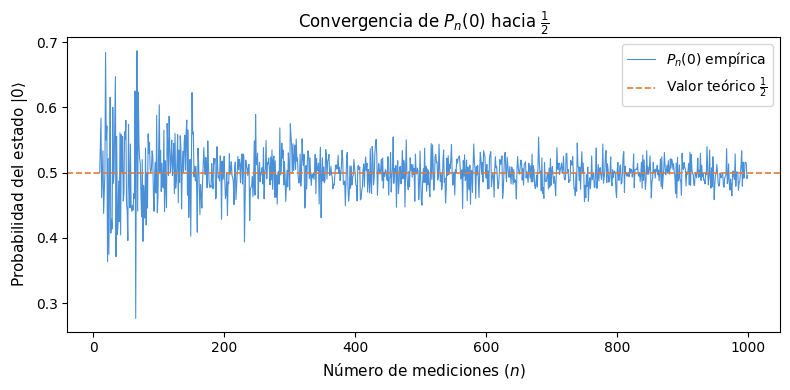

In [2]:
def main(copies_low=10, copies_high=1000):
    probability_for_zero_state_trace = []
    copies_trace = []

    for n in range(copies_low, copies_high):
        copies_trace.append(n)
        prob_0 = hadamard_state_measurement(n)
        probability_for_zero_state_trace.append(prob_0)

    plt.figure(figsize=(8, 4))
    plt.plot(copies_trace, probability_for_zero_state_trace, linewidth=0.8, color='#4a90d9', label='$P_n(0)$ empírica')
    plt.axhline(0.5, color='#e07b39', linestyle='--', linewidth=1.2, label='Valor teórico $\\frac{1}{2}$')
    plt.xlabel('Número de mediciones ($n$)', fontsize=11)
    plt.ylabel('Probabilidad del estado $|0\\rangle$', fontsize=11)
    plt.title('Convergencia de $P_n(0)$ hacia $\\frac{1}{2}$', fontsize=12)
    plt.legend(fontsize=10)
    plt.spines = None
    plt.tight_layout()
    plt.show()


main()

### Observaciones

- Para $n$ pequeño (10–100) las oscilaciones son grandes: la muestra no es suficiente para estabilizar la probabilidad.
- A partir de $n \approx 500$ la curva se estrecha alrededor de 0.5 con oscilaciones menores.
- Este comportamiento es una manifestación de la **ley de los grandes números** aplicada a la medición cuántica.